# CUPED — variance reduction is a bet on a correlation you already collected

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/cuped-variance/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/cuped-variance/demo.ipynb)

Somebody says the test needs six weeks and somebody else says CUPED will halve it. The
first claim is arithmetic. The second is a claim about a **correlation** — and it is only
true at a correlation of 0.707, because everything CUPED can ever return is that
correlation *squared*.

This notebook measures what the pre-period is actually worth on worlds with a known 2%
effect and a known pre/post correlation, and then measures the four ways the number comes
apart. Two of them are not statistics problems at all — they are a missing-data policy and
a column timestamp, and each one can reverse the sign of the whole exercise.

Reference: Deng, Xu, Kohavi & Walker (2013), *Improving the Sensitivity of Online
Controlled Experiments by Utilizing Pre-Experiment Data* (WSDM).

**What it covers**

1. The core logic — one world, four adjusters, the closed forms
2. The null has to hold before any reduction can be measured
3. The whole result is rho squared — and rho = 0.5 is not half
4. **Negative result:** "just subtract the pre-period" can triple the variance
5. **Negative result:** mean-imputing the missing covariate stops helping at exactly 50% new users
6. **Negative result:** on a revenue-shaped metric you cannot measure rho at all
7. The mistake that looks identical in code: a covariate from after assignment
8. One figure, a summary, and a "try your own" cell

## 1. The core logic

Three parts. The **world** produces pre-period and in-experiment values correlated at a
rho we set. The **adjusters** differ only in what they do with the pre-period column. The
**closed forms** give the arithmetic answer, so the simulation is checked against algebra
rather than against itself.

Two details in `simulate` are worth reading. Assignment randomises the *traffic* between
arms rather than giving each arm a quota — without that the estimator has no null
distribution. And `theta` is fitted on the two arms **centred separately** before pooling,
so the treatment effect cannot leak into the covariance that sets the coefficient.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats

TRIALS = 3000     # simulated experiments per cell (raise it if you have time)
SEED = 20260904


# ---- the world ----------------------------------------------------------
# Two things matter about it. The pre-period and in-experiment values are
# correlated at a rho we SET rather than estimate, so every claim below has an
# answer to be checked against. And the assignment randomises the traffic
# between arms rather than handing each arm a quota, which is what gives the
# estimator a null distribution at all.

@dataclass(frozen=True)
class World:
    per_arm: int = 3_000
    rho: float = 0.60          # correlation of pre-period and in-experiment value
    mean: float = 10.0
    sd: float = 4.0
    sd_pre: Optional[float] = None   # a longer pre-window has a LARGER sd
    true_rel_lift: float = 0.02
    new_user_share: float = 0.0      # users with no pre-period at all
    lognormal: bool = False          # the revenue-shaped case
    log_sigma: float = 1.0

    @property
    def true_effect(self):
        return self.mean * self.true_rel_lift

    @property
    def sd_pre_eff(self):
        return self.sd if self.sd_pre is None else self.sd_pre

W = World()

def simulate(world, trials, rng, effect_on_pre=False):
    """effect_on_pre=True is the mistake in section 6: a covariate the treatment moved."""
    m = world.per_arm
    shape = (trials, m)

    def draw():
        z1, z2 = rng.standard_normal(shape), rng.standard_normal(shape)
        post_std = world.rho * z1 + np.sqrt(max(1 - world.rho ** 2, 0)) * z2
        if world.lognormal:
            s = world.log_sigma
            mu = np.exp(s * s / 2)
            sd = mu * np.sqrt(np.exp(s * s) - 1)
            pre = world.mean + world.sd_pre_eff * (np.exp(s * z1) - mu) / sd
            post = world.mean + world.sd * (np.exp(s * post_std) - mu) / sd
        else:
            pre = world.mean + world.sd_pre_eff * z1
            post = world.mean + world.sd * post_std
        return pre, post

    pre_c, post_c = draw()
    pre_t, post_t = draw()
    post_t = post_t + world.true_effect
    if effect_on_pre:
        pre_t = pre_t + world.true_effect

    f = world.new_user_share
    new_c = rng.random(shape) < f if f > 0 else np.zeros(shape, bool)
    new_t = rng.random(shape) < f if f > 0 else np.zeros(shape, bool)
    return {"pre_c": pre_c, "post_c": post_c, "pre_t": pre_t, "post_t": post_t,
            "new_c": new_c, "new_t": new_t}


# ---- the adjusters ------------------------------------------------------
# They differ ONLY in what they do with the pre-period column.

def _impute(pre, is_new):
    """Replace a missing pre-period value with the observed mean, per trial."""
    if not is_new.any():
        return pre
    out = pre.copy()
    for i in range(pre.shape[0]):
        mask = is_new[i]
        if not mask.all():
            out[i][mask] = pre[i][~mask].mean()
    return out

def _welch_se(a, b):
    return np.sqrt(a.var(axis=1, ddof=1) / a.shape[1] + b.var(axis=1, ddof=1) / b.shape[1])

def adj_none(d):
    yc, yt = d["post_c"], d["post_t"]
    return yt.mean(axis=1) - yc.mean(axis=1), _welch_se(yt, yc)

def _core(d, theta_mode):
    yc, yt = d["post_c"], d["post_t"]
    xc, xt = _impute(d["pre_c"], d["new_c"]), _impute(d["pre_t"], d["new_t"])

    def theta_of(x, y):
        xm = x - x.mean(axis=1, keepdims=True)
        ym = y - y.mean(axis=1, keepdims=True)
        v = (xm * xm).mean(axis=1)
        return np.divide((xm * ym).mean(axis=1), v, out=np.zeros_like(v), where=v > 0)

    if theta_mode == "pooled":
        # Centre each arm before pooling so the treatment effect cannot leak
        # into the covariance that sets theta.
        xa = np.concatenate([xc - xc.mean(axis=1, keepdims=True),
                             xt - xt.mean(axis=1, keepdims=True)], axis=1)
        ya = np.concatenate([yc - yc.mean(axis=1, keepdims=True),
                             yt - yt.mean(axis=1, keepdims=True)], axis=1)
        th_c = th_t = theta_of(xa, ya)
    elif theta_mode == "unit":
        th_c = th_t = np.ones(yc.shape[0])
    else:
        raise ValueError(theta_mode)

    grand = np.concatenate([xc, xt], axis=1).mean(axis=1, keepdims=True)
    ac = yc - th_c[:, None] * (xc - grand)
    at = yt - th_t[:, None] * (xt - grand)
    return at.mean(axis=1) - ac.mean(axis=1), _welch_se(at, ac)

def adj_cuped(d):
    """CUPED: one theta fitted on both arms pooled."""
    return _core(d, "pooled")

def adj_diff_in_diff(d):
    """theta forced to 1 - 'just subtract each user's pre-period value'."""
    return _core(d, "unit")

def adj_cuped_stratified(d):
    """CUPED among users who HAVE a pre-period, plain difference among those who do not."""
    yc, yt, xc, xt = d["post_c"], d["post_t"], d["pre_c"], d["pre_t"]
    nc, nt = d["new_c"], d["new_t"]
    trials = yc.shape[0]
    est, var = np.zeros(trials), np.zeros(trials)
    for i in range(trials):
        rc, rt = ~nc[i], ~nt[i]
        n_ret, n_new = int(rc.sum() + rt.sum()), int(nc[i].sum() + nt[i].sum())
        n_all = n_ret + n_new
        parts = []
        if rc.sum() > 2 and rt.sum() > 2:
            xr = np.concatenate([xc[i][rc] - xc[i][rc].mean(), xt[i][rt] - xt[i][rt].mean()])
            yr = np.concatenate([yc[i][rc] - yc[i][rc].mean(), yt[i][rt] - yt[i][rt].mean()])
            th = float((xr * yr).mean() / (xr * xr).mean()) if (xr * xr).mean() > 0 else 0.0
            g = np.concatenate([xc[i][rc], xt[i][rt]]).mean()
            ac, at = yc[i][rc] - th * (xc[i][rc] - g), yt[i][rt] - th * (xt[i][rt] - g)
            parts.append((n_ret / n_all, at.mean() - ac.mean(),
                          at.var(ddof=1) / rt.sum() + ac.var(ddof=1) / rc.sum()))
        if nc[i].sum() > 2 and nt[i].sum() > 2:
            parts.append((n_new / n_all, yt[i][nt[i]].mean() - yc[i][nc[i]].mean(),
                          yt[i][nt[i]].var(ddof=1) / nt[i].sum()
                          + yc[i][nc[i]].var(ddof=1) / nc[i].sum()))
        w = sum(x[0] for x in parts) or 1.0
        est[i] = sum(p[0] / w * p[1] for p in parts)
        var[i] = sum((p[0] / w) ** 2 * p[2] for p in parts)
    return est, np.sqrt(var)


# ---- closed forms -------------------------------------------------------

def variance_reduction(rho):
    """The entire CUPED result: Var(Y_cuped)/Var(Y) = 1 - rho^2."""
    return rho * rho

def sample_size_multiplier(rho):
    return 1 - rho * rho

def variance_ratio_unit_theta(rho, sd_pre, sd_post):
    """Var(Y - X)/Var(Y). Exceeds 1 whenever sd_pre > 2 rho sd_post."""
    return (sd_post ** 2 + sd_pre ** 2 - 2 * rho * sd_pre * sd_post) / sd_post ** 2

def reduction_mean_impute(rho, f):
    """rho^2 (2 - 1/(1-f)) - zero at f = 0.5, negative beyond, for ANY rho."""
    return -np.inf if f >= 1 else rho * rho * (2 - 1 / (1 - f))

def reduction_stratified(rho, f):
    """(1-f) rho^2 - what the naive version is usually credited with."""
    return (1 - f) * rho * rho

def lognormal_pearson_rho(log_rho, sigma):
    """Pearson correlation of two lognormals whose LOGS correlate at log_rho."""
    return (np.exp(log_rho * sigma * sigma) - 1) / (np.exp(sigma * sigma) - 1)


# ---- scoring ------------------------------------------------------------

def score(est, se, true_effect, alpha=0.05):
    z = stats.norm.isf(alpha / 2)
    lo, hi = est - z * se, est + z * se
    return {"mean_est": float(est.mean()), "bias": float(est.mean() - true_effect),
            "sd_est": float(est.std(ddof=1)), "reject_rate": float((np.abs(est) > z * se).mean()),
            "coverage": float(((lo <= true_effect) & (true_effect <= hi)).mean())}

def reduction_with_mc(est, base, resamples=200, seed=0):
    """The measured reduction AND its own bootstrap error.

    A reduction is a ratio of two sample variances, so it has sampling error of
    its own. Without the error bar, ordinary noise looks like a broken
    derivation - and a broken derivation hides inside the noise.
    """
    t = min(len(est), len(base))
    est, base = np.asarray(est[:t]), np.asarray(base[:t])
    point = 1 - (est.std(ddof=1) / base.std(ddof=1)) ** 2
    if t < 200:
        return point, float("nan")
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, t, size=(resamples, t))
    boot = 1 - (est[idx].std(axis=1, ddof=1) / base[idx].std(axis=1, ddof=1)) ** 2
    return float(point), float(boot.std(ddof=1))

print(f"world: {W.per_arm:,} per arm, metric mean {W.mean} sd {W.sd}, "
      f"true relative lift {W.true_rel_lift:.0%}, rho = {W.rho}")


world: 3,000 per arm, metric mean 10.0 sd 4.0, true relative lift 2%, rho = 0.6


## 2. The null has to hold first

Before measuring how much variance anything removes, the world with no effect in it must
reject at exactly the advertised rate and cover at exactly the nominal level. A
variance-reduction harness with a broken null cannot measure a reduction — it can only
report one, and the failure makes the method look *better* than it is.

In [2]:
rng = np.random.default_rng(SEED)
d0 = simulate(World(true_rel_lift=0.0), 6000, rng)

rows = []
for name, fn in (("none", adj_none), ("cuped", adj_cuped),
                 ("diff_in_diff", adj_diff_in_diff)):
    s = score(*fn(d0), 0.0)
    rows.append({"adjuster": name, "size (nominal 0.05)": round(s["reject_rate"], 4),
                 "coverage (nominal 0.95)": round(s["coverage"], 4),
                 "sd of the estimate": round(s["sd_est"], 5)})
display(pd.DataFrame(rows))

b, _ = adj_none(d0)
c, _ = adj_cuped(d0)
pt, se = reduction_with_mc(c, b)
print(f"predicted reduction = rho^2 = {variance_reduction(W.rho):.4f}")
print(f"measured on 6,000 null experiments = {pt:.4f} +/- {se:.4f}")
print("\nThe error bar matters. A reduction is a RATIO of two sample variances, so it")
print("has sampling error of its own - without it, ordinary noise reads as a broken")
print("derivation, and a broken derivation hides inside the noise.")

,adjuster,size (nominal 0.05),coverage (nominal 0.95),sd of the estimate
0,none,0.0527,0.9473,0.10351
1,cuped,0.0522,0.9478,0.08335
2,diff_in_diff,0.0520,0.9480,0.09237


predicted reduction = rho^2 = 0.3600
measured on 6,000 null experiments = 0.3516 +/- 0.0097

The error bar matters. A reduction is a RATIO of two sample variances, so it
has sampling error of its own - without it, ordinary noise reads as a broken
derivation, and a broken derivation hides inside the noise.


## 3. The whole result is rho squared

Two consequences people get wrong in opposite directions. A correlation of 0.5 sounds
strong and returns a quarter of the traffic. And "CUPED halves the test" is a statement
about rho = 0.707, not about CUPED.

In [3]:
rows = []
for r in (0.2, 0.3, 0.4, 0.5, 0.6, 0.70710678, 0.8, 0.9):
    m = sample_size_multiplier(r)
    rows.append({"rho": round(r, 3), "variance removed": f"{1-m:.1%}",
                 "traffic needed": f"{m:.3f}x", "a 6-week test becomes": f"{6*m:.2f} weeks"})
display(pd.DataFrame(rows))

d = simulate(W, TRIALS, rng)
base, _ = adj_none(d)
rows = []
for name, fn in (("none", adj_none), ("diff_in_diff", adj_diff_in_diff),
                 ("cuped", adj_cuped)):
    est, se_ = fn(d)
    s = score(est, se_, W.true_effect)
    pt, mc = reduction_with_mc(est, base)
    rows.append({"adjuster": name, "power": round(s["reject_rate"], 4),
                 "reduction": f"{pt:.4f} +/- {mc:.3f}", "traffic needed": f"{1-pt:.3f}x",
                 "bias": round(s["bias"], 5), "coverage": round(s["coverage"], 4)})
display(pd.DataFrame(rows))
print("Same data, same effect: CUPED moves power from ~0.49 to ~0.68 and needs ~0.64x the")
print("traffic. Every adjuster here is unbiased and covers at nominal - they differ only")
print("in spread, which is the whole point and also the whole risk.")

,rho,variance removed,traffic needed,a 6-week test becomes
0,0.200,4.0%,0.960x,5.76 weeks
1,0.300,9.0%,0.910x,5.46 weeks
2,0.400,16.0%,0.840x,5.04 weeks
3,0.500,25.0%,0.750x,4.50 weeks
4,0.600,36.0%,0.640x,3.84 weeks
5,0.707,50.0%,0.500x,3.00 weeks
6,0.800,64.0%,0.360x,2.16 weeks
7,0.900,81.0%,0.190x,1.14 weeks


,adjuster,power,reduction,traffic needed,bias,coverage
0,none,0.4920,0.0000 +/- 0.000,1.000x,-0.00126,0.9497
1,diff_in_diff,0.5723,0.1742 +/- 0.026,0.826x,-0.00130,0.9460
2,cuped,0.6807,0.3483 +/- 0.014,0.652x,-0.00131,0.9513


Same data, same effect: CUPED moves power from ~0.49 to ~0.68 and needs ~0.64x the
traffic. Every adjuster here is unbiased and covers at nominal - they differ only
in spread, which is the whole point and also the whole risk.


## 4. Negative result: "just subtract the pre-period" can triple the variance

The instinct is to subtract each user's own before-value. That is CUPED with the
coefficient **guessed at 1** instead of fitted, and

    Var(Y - X) = sd_post² + sd_pre² - 2·rho·sd_pre·sd_post

which exceeds Var(Y) whenever `sd_pre > 2·rho·sd_post`. A month of pre-period history
against a week of test window is the normal case, and it is exactly the case where the
guess fails.

In [4]:
rows = []
for sd_pre, rho in ((4.0, 0.60), (4.0, 0.30), (6.0, 0.40), (8.0, 0.40)):
    w = World(sd_pre=sd_pre, rho=rho, true_rel_lift=0.0)
    dv = simulate(w, TRIALS, rng)
    bb, _ = adj_none(dv)
    uu, _ = adj_diff_in_diff(dv)
    cc, _ = adj_cuped(dv)
    ratio = (uu.std(ddof=1) / bb.std(ddof=1)) ** 2
    _, mc = reduction_with_mc(uu, bb)
    rows.append({"sd_pre": sd_pre, "sd_post": w.sd, "rho": rho,
                 "theta = 1, closed form": round(variance_ratio_unit_theta(rho, sd_pre, w.sd), 4),
                 "theta = 1, measured": f"{ratio:.4f} +/- {mc:.3f}",
                 "theta* (fitted)": round(rho * w.sd / sd_pre, 4),
                 "fitted theta reduction": round(reduction_with_mc(cc, bb)[0], 4)})
display(pd.DataFrame(rows))
print("Bottom row: a pre-window twice as wide, correlation 0.40. Subtracting the")
print("pre-period multiplies the variance by ~3.4 - the test needs 3.4x the traffic -")
print("while fitting the same covariate's coefficient still returns ~0.16.")
print("Same column, same data, opposite sign of outcome.")

,sd_pre,sd_post,rho,"theta = 1, closed form","theta = 1, measured",theta* (fitted),fitted theta reduction
0,4.0,4.0,0.6,0.80,0.8381 +/- 0.023,0.6000,0.3369
1,4.0,4.0,0.3,1.40,1.4335 +/- 0.043,0.3000,0.0807
2,6.0,4.0,0.4,2.05,2.1108 +/- 0.074,0.2667,0.1420
3,8.0,4.0,0.4,3.40,3.4127 +/- 0.132,0.2000,0.1512


Bottom row: a pre-window twice as wide, correlation 0.40. Subtracting the
pre-period multiplies the variance by ~3.4 - the test needs 3.4x the traffic -
while fitting the same covariate's coefficient still returns ~0.16.
Same column, same data, opposite sign of outcome.


## 5. Negative result: mean-imputing the missing covariate stops helping at f = 0.5

Users with no pre-period get the mean. Every implementation does this, and every write-up
says the reduction becomes `(1-f)·rho²`. That is the **per-user** variance.

The estimator is a difference of arm **means**. Once the covariate is imputed, the arm's
covariate mean is the mean of the *returning* users only, so its variance is
`σ²/(n(1-f))`, not `σ²/n`. Writing out
`Var(ΔY - θΔX) = 2σ_y²/n · [1 + rho²/(1-f) - 2rho²]` leaves

    reduction = rho² · (2 - 1/(1-f))

which is **zero at f = 0.5 and negative beyond, for any rho at all**.

In [5]:
rho_n = 0.70
rows = []
for f in (0.0, 0.2, 0.4, 0.5, 0.6, 0.8):
    w = World(rho=rho_n, new_user_share=f, true_rel_lift=0.0)
    df = simulate(w, 1500, rng)
    bb, _ = adj_none(df)
    ii, _ = adj_cuped(df)
    ss, _ = adj_cuped_stratified(df)
    p1, e1 = reduction_with_mc(ii, bb)
    p2, e2 = reduction_with_mc(ss, bb)
    rows.append({"new users": f"{f:.0%}",
                 "textbook (1-f)rho^2": round(reduction_stratified(rho_n, f), 4),
                 "derived rho^2(2-1/(1-f))": round(reduction_mean_impute(rho_n, f), 4),
                 "measured, mean-impute": f"{p1:+.4f} +/- {e1:.3f}",
                 "measured, stratified": f"{p2:+.4f} +/- {e2:.3f}"})
display(pd.DataFrame(rows))

print("The break-even does not depend on rho at all:")
for r in (0.3, 0.5, 0.7, 0.9):
    print(f"   rho = {r}: reduction at f = 0.5 is {reduction_mean_impute(r, 0.5):+.6f}")
print("\nAt 60% new users mean-imputation is a variance INCREASE, while treating")
print("'has a pre-period' as a stratum still returns about (1-f)rho^2. The fix is three")
print("lines: run CUPED inside the users who have a pre-period, take a plain difference")
print("inside those who do not, and combine by their share.")

,new users,textbook (1-f)rho^2,derived rho^2(2-1/(1-f)),"measured, mean-impute","measured, stratified"
0,0%,0.490,0.4900,+0.4849 +/- 0.017,+0.4849 +/- 0.017
1,20%,0.392,0.3675,+0.3489 +/- 0.026,+0.3814 +/- 0.021
2,40%,0.294,0.1633,+0.1660 +/- 0.035,+0.2947 +/- 0.019
3,50%,0.245,0.0000,-0.0175 +/- 0.043,+0.2381 +/- 0.019
4,60%,0.196,-0.2450,-0.3461 +/- 0.063,+0.1667 +/- 0.020
5,80%,0.098,-1.4700,-1.4188 +/- 0.124,+0.1003 +/- 0.014


The break-even does not depend on rho at all:
   rho = 0.3: reduction at f = 0.5 is +0.000000
   rho = 0.5: reduction at f = 0.5 is +0.000000
   rho = 0.7: reduction at f = 0.5 is +0.000000
   rho = 0.9: reduction at f = 0.5 is +0.000000

At 60% new users mean-imputation is a variance INCREASE, while treating
'has a pre-period' as a stratum still returns about (1-f)rho^2. The fix is three
lines: run CUPED inside the users who have a pre-period, take a plain difference
inside those who do not, and combine by their share.


## 6. Negative result: on a revenue-shaped metric you cannot measure rho at all

CUPED runs on the Pearson correlation of the metric **as reported**, not of its log.
Exponentiate both margins and a relationship that is 0.80 on the log scale becomes much
weaker on the reported scale — and the *sample* correlation, the number you would compute
to decide whether CUPED is worth doing, is biased upward and wildly unstable.

In [6]:
rows = []
for sig in (0.5, 1.0, 1.5, 2.0):
    w = World(rho=0.80, lognormal=True, log_sigma=sig, true_rel_lift=0.0)
    dt = simulate(w, 1200, rng)
    samp = np.array([np.corrcoef(dt["pre_c"][i], dt["post_c"][i])[0, 1] for i in range(250)])
    bb, _ = adj_none(dt)
    cc, _ = adj_cuped(dt)
    p, e = reduction_with_mc(cc, bb)
    pop = lognormal_pearson_rho(0.80, sig)
    rows.append({"lognormal sigma": sig, "population rho": round(pop, 4),
                 "sample rho": f"{samp.mean():.4f} +/- {samp.std(ddof=1):.3f}",
                 "population rho^2": round(pop ** 2, 4),
                 "measured reduction": f"{p:.4f} +/- {e:.3f}"})
display(pd.DataFrame(rows))
print("At sigma 2.0 the population correlation is ~0.44 and the sample reads ~0.53 with a")
print("spread of ~0.13 - biased up about 21%, and wide enough that two honest analysts on")
print("the same table would quote correlations 0.3 apart.")
print("\nThe delivered reduction stops being predictable by either number: at that tail")
print("weight the sample variance is itself set by a handful of users, so the RATIO of two")
print("sample variances has an error bar wide enough to swallow the effect. The honest")
print("reading is NOT 'CUPED beats rho^2 on heavy tails' - it is that neither the planning")
print("number nor the delivered number is measurable to the precision anyone quotes.")
print("Cap or winsorise first, quote an interval, and re-measure after the cap.")

,lognormal sigma,population rho,sample rho,population rho^2,measured reduction
0,0.5,0.7795,0.7799 +/- 0.010,0.6076,0.6360 +/- 0.017
1,1.0,0.7132,0.7174 +/- 0.028,0.5087,0.5244 +/- 0.020
2,1.5,0.5949,0.6196 +/- 0.087,0.3539,0.4455 +/- 0.031
3,2.0,0.4391,0.5173 +/- 0.143,0.1928,0.4606 +/- 0.128


At sigma 2.0 the population correlation is ~0.44 and the sample reads ~0.53 with a
spread of ~0.13 - biased up about 21%, and wide enough that two honest analysts on
the same table would quote correlations 0.3 apart.

The delivered reduction stops being predictable by either number: at that tail
weight the sample variance is itself set by a handful of users, so the RATIO of two
sample variances has an error bar wide enough to swallow the effect. The honest
reading is NOT 'CUPED beats rho^2 on heavy tails' - it is that neither the planning
number nor the delivered number is measurable to the precision anyone quotes.
Cap or winsorise first, quote an interval, and re-measure after the cap.


## 7. The mistake that looks identical in code

Everything above needs the covariate to **predate randomisation**. Take a covariate the
treatment also moved — same-period engagement, a metric the variant changed — and the
adjustment removes the treatment effect as if it were noise. The diff is three lines, the
code path is identical, and it reviews clean.

In [7]:
rows = []
for label, flag in (("pre-period (correct)", False), ("post-assignment", True)):
    dp = simulate(W, 4000, rng, effect_on_pre=flag)
    for nm, fn in (("none", adj_none), ("cuped", adj_cuped)):
        s = score(*fn(dp), W.true_effect)
        rows.append({"covariate": label, "adjuster": nm,
                     "estimate": round(s["mean_est"], 4), "true": round(W.true_effect, 4),
                     "bias as % of effect": f"{s['bias']/W.true_effect:+.1%}",
                     "power": round(s["reject_rate"], 4),
                     "coverage": round(s["coverage"], 4)})
display(pd.DataFrame(rows))
print("The unadjusted estimator finds the effect either way. CUPED on the post-assignment")
print("covariate reports roughly 40% of it, with coverage near 0.70 against a nominal 0.95,")
print("and LOWER power than doing nothing.")
print("\nVariance reduction and effect destruction are the same operation pointed at")
print("different columns, and only the column's timestamp tells them apart. That makes it a")
print("data-contract question, not a statistics question: the covariate table needs a hard")
print("cutoff at the assignment timestamp, enforced somewhere a reviewer can see it.")

,covariate,adjuster,estimate,true,bias as % of effect,power,coverage
0,pre-period (correct),none,0.1995,0.2,-0.3%,0.4930,0.9490
1,pre-period (correct),cuped,0.1997,0.2,-0.1%,0.6767,0.9515
2,post-assignment,none,0.1998,0.2,-0.1%,0.4890,0.9555
3,post-assignment,cuped,0.0794,0.2,-60.3%,0.1562,0.6897


The unadjusted estimator finds the effect either way. CUPED on the post-assignment
covariate reports roughly 40% of it, with coverage near 0.70 against a nominal 0.95,
and LOWER power than doing nothing.

Variance reduction and effect destruction are the same operation pointed at
different columns, and only the column's timestamp tells them apart. That makes it a
data-contract question, not a statistics question: the covariate table needs a hard
cutoff at the assignment timestamp, enforced somewhere a reviewer can see it.


## 8. The picture

Four panels: the rho-squared curve, what theta = 1 costs as the pre-window widens, the
imputation break-even, and the post-assignment covariate.

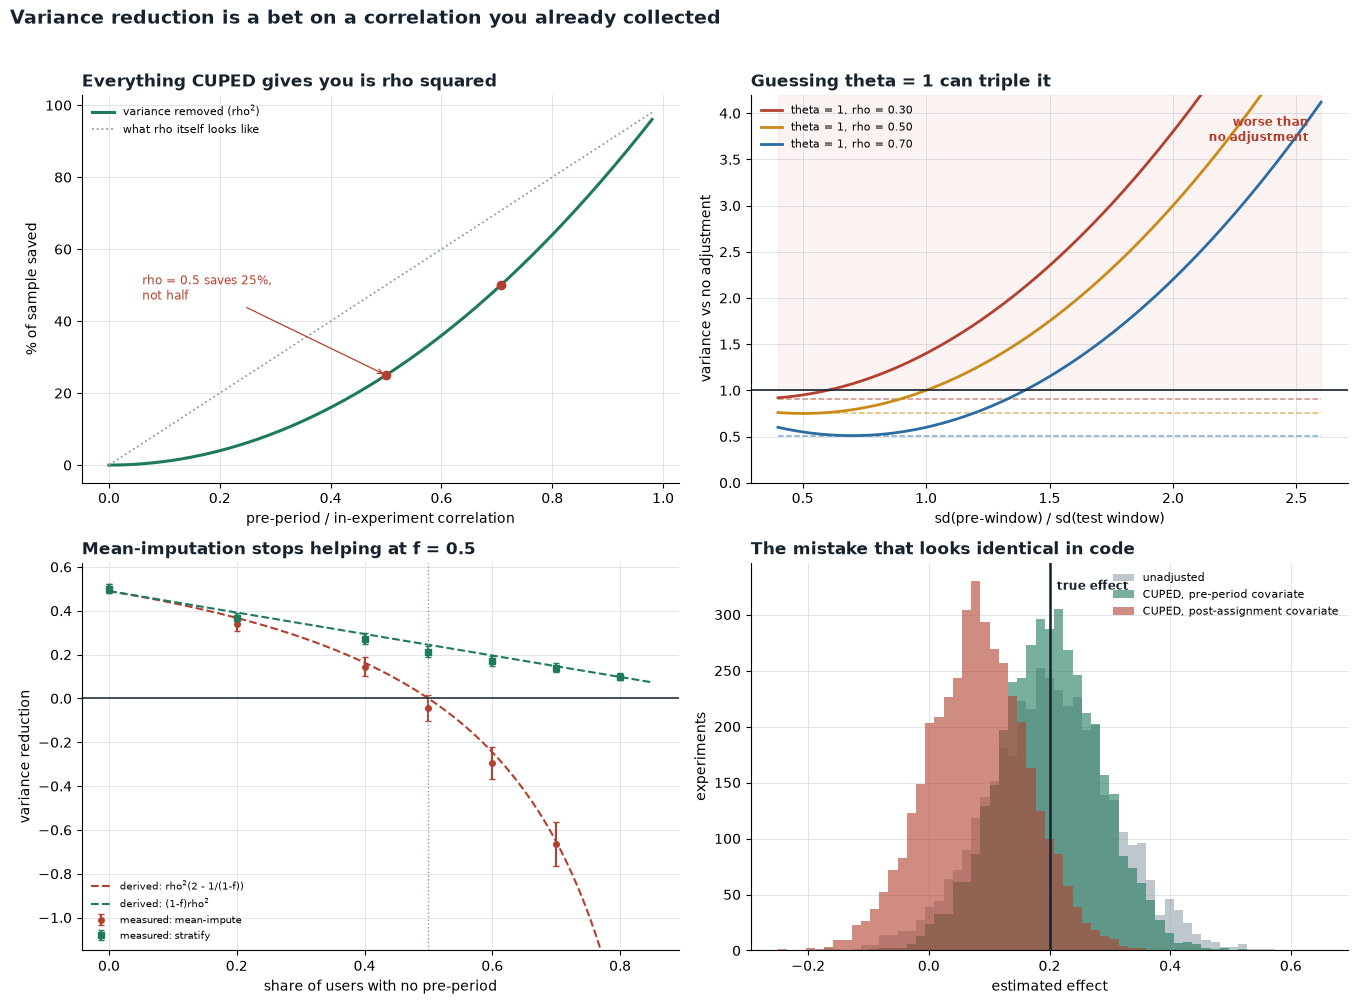

In [8]:
import matplotlib.pyplot as plt

INK, MUTE, GOOD, BAD, WARN, COOL, PLUM, GRID = ("#16222e", "#8b9aa7", "#1f7a5c", "#b3402f",
                                                "#c98a1a", "#2b6ca3", "#6b4d8f", "#dfe5ea")
fig, ax = plt.subplots(2, 2, figsize=(13.6, 10.2))
fig.patch.set_facecolor("white")

# (a) rho^2
rr = np.linspace(0, 0.98, 300)
ax[0][0].plot(rr, variance_reduction(rr) * 100, color=GOOD, lw=2.2, label="variance removed (rho$^2$)")
ax[0][0].plot(rr, rr * 100, color=MUTE, lw=1.3, ls=":", label="what rho itself looks like")
for r in (0.5, 0.70710678):
    ax[0][0].plot([r], [variance_reduction(r) * 100], "o", ms=6, color=BAD)
ax[0][0].annotate("rho = 0.5 saves 25%,\nnot half", xy=(0.5, 25), xytext=(0.06, 46),
                  fontsize=8.5, color=BAD, arrowprops=dict(arrowstyle="->", color=BAD, lw=0.9))
ax[0][0].set_xlabel("pre-period / in-experiment correlation"); ax[0][0].set_ylabel("% of sample saved")
ax[0][0].set_title("Everything CUPED gives you is rho squared", fontweight="bold", loc="left", color=INK)
ax[0][0].legend(frameon=False, fontsize=8, loc="upper left")

# (b) theta = 1
ratios = np.linspace(0.4, 2.6, 200)
for rho, colour in ((0.30, BAD), (0.50, WARN), (0.70, COOL)):
    ax[0][1].plot(ratios, [variance_ratio_unit_theta(rho, r * 4, 4) for r in ratios],
                  color=colour, lw=2, label=f"theta = 1, rho = {rho:.2f}")
    ax[0][1].plot(ratios, [1 - rho ** 2] * len(ratios), color=colour, lw=1.1, ls="--", alpha=0.6)
ax[0][1].axhline(1.0, color=INK, lw=1.2)
ax[0][1].fill_between(ratios, 1.0, 4.2, color=BAD, alpha=0.06)
ax[0][1].text(2.55, 3.7, "worse than\nno adjustment", fontsize=8.4, color=BAD, ha="right", fontweight="bold")
ax[0][1].set_ylim(0, 4.2)
ax[0][1].set_xlabel("sd(pre-window) / sd(test window)"); ax[0][1].set_ylabel("variance vs no adjustment")
ax[0][1].set_title("Guessing theta = 1 can triple it", fontweight="bold", loc="left", color=INK)
ax[0][1].legend(frameon=False, fontsize=7.8, loc="upper left")

# (c) imputation break-even
fs = np.array([0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8])
imp, strat, ie, se_ = [], [], [], []
for f in fs:
    w = World(rho=0.7, new_user_share=float(f), true_rel_lift=0.0)
    df = simulate(w, 1000, rng)
    bb, _ = adj_none(df)
    p1, e1 = reduction_with_mc(adj_cuped(df)[0], bb)
    p2, e2 = reduction_with_mc(adj_cuped_stratified(df)[0], bb)
    imp.append(p1); ie.append(e1); strat.append(p2); se_.append(e2)
grid = np.linspace(0, 0.85, 150)
ax[1][0].plot(grid, [reduction_mean_impute(0.7, f) for f in grid], color=BAD, lw=1.5, ls="--",
              label="derived: rho$^2$(2 - 1/(1-f))")
ax[1][0].plot(grid, [reduction_stratified(0.7, f) for f in grid], color=GOOD, lw=1.5, ls="--",
              label="derived: (1-f)rho$^2$")
ax[1][0].errorbar(fs, imp, yerr=ie, fmt="o", ms=4, color=BAD, capsize=2, label="measured: mean-impute")
ax[1][0].errorbar(fs, strat, yerr=se_, fmt="s", ms=4, color=GOOD, capsize=2, label="measured: stratify")
ax[1][0].axhline(0, color=INK, lw=1.1); ax[1][0].axvline(0.5, color=MUTE, lw=1, ls=":")
ax[1][0].set_ylim(-1.15, 0.62)
ax[1][0].set_xlabel("share of users with no pre-period"); ax[1][0].set_ylabel("variance reduction")
ax[1][0].set_title("Mean-imputation stops helping at f = 0.5", fontweight="bold", loc="left", color=INK)
ax[1][0].legend(frameon=False, fontsize=7.4, loc="lower left")

# (d) post-assignment covariate
dg = simulate(W, 4000, rng, effect_on_pre=False)
db = simulate(W, 4000, rng, effect_on_pre=True)
bins = np.linspace(-0.25, 0.65, 60)
ax[1][1].hist(adj_none(db)[0], bins=bins, color=MUTE, alpha=0.55, label="unadjusted")
ax[1][1].hist(adj_cuped(dg)[0], bins=bins, color=GOOD, alpha=0.6, label="CUPED, pre-period covariate")
ax[1][1].hist(adj_cuped(db)[0], bins=bins, color=BAD, alpha=0.6, label="CUPED, post-assignment covariate")
ax[1][1].axvline(W.true_effect, color=INK, lw=1.8)
ax[1][1].text(W.true_effect + 0.012, ax[1][1].get_ylim()[1] * 0.93, "true effect",
              fontsize=8.4, color=INK, fontweight="bold")
ax[1][1].set_xlabel("estimated effect"); ax[1][1].set_ylabel("experiments")
ax[1][1].set_title("The mistake that looks identical in code", fontweight="bold", loc="left", color=INK)
ax[1][1].legend(frameon=False, fontsize=7.6, loc="upper right")

for a in ax.ravel():
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(True, color=GRID, lw=0.7); a.set_axisbelow(True)
fig.suptitle("Variance reduction is a bet on a correlation you already collected",
             fontsize=13.5, fontweight="bold", color=INK, x=0.005, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.savefig("cuped_notebook_figure.png", dpi=150, facecolor="white")
plt.show()

## Summary

| claim | measured |
|---|---|
| the null holds for every adjuster | size ~0.05, coverage ~0.95 |
| the reduction is rho squared | 0.36 promised, ~0.35 ± 0.01 measured at rho = 0.6 |
| what it is worth | power 0.49 → 0.68 on identical data, 0.64x the traffic |
| rho = 0.5 | 25% of the sample, so 6 weeks → 4.5, not 3 |
| to halve the test | rho = 0.707 |
| **negative result** | theta = 1 with a 2x-wider pre-window: **3.4x** the variance |
| **negative result** | mean-imputation break-even at **f = 0.5**, for any rho; at f = 0.8 it is a 2.4x variance *increase* while stratifying still returns 0.098 |
| **negative result** | on a lognormal-sigma-2 metric the sample correlation is biased up 21% with a ±0.13 spread |
| post-assignment covariate | −59% of the effect, coverage 0.70, power 0.51 → 0.17 |
| per-arm theta | identical to pooled to 7 decimals, even with a multiplicative effect |
| theta estimation at n = 20/arm | size 0.065 vs 0.058, and 0.34 of the 0.36 already delivered |

**What to do with it**

1. Compute the correlation first, on last quarter's data. Everything CUPED will ever give
   you is rho² — and rho = 0.5 buys 25%, not half.
2. Fit theta. Never assume 1.
3. Stratify on "has a pre-period" instead of imputing the mean. Past 50% new users,
   imputation is worse than doing nothing, for **any** correlation.
4. Put a hard cutoff at the assignment timestamp on the covariate table, and review it.
5. On a heavy-tailed metric, cap or winsorise before quoting a correlation, and report an
   interval on it.
6. Report the reduction you **measured** next to the rho² you promised. They agree in the
   clean case, and every negative result above is a way they come apart.

In [9]:
# ---- Try your own -------------------------------------------------------
# Uncomment and edit. Everything above is recomputed from these knobs.

# 1. Your correlation, your timeline
# my_rho, my_weeks = 0.42, 8
# m = sample_size_multiplier(my_rho)
# print(f"rho {my_rho}: {1-m:.1%} of the sample saved; {my_weeks} weeks -> {my_weeks*m:.1f}")

# 2. Would theta = 1 hurt you? (measure both sds on real data first)
# print(variance_ratio_unit_theta(my_rho, sd_pre=9.0, sd_post=4.0))   # > 1 means it hurts

# 3. Your new-user share
# for f in (0.1, 0.3, 0.5, 0.7):
#     print(f, round(reduction_mean_impute(my_rho, f), 4), round(reduction_stratified(my_rho, f), 4))

# 4. Two covariates instead of one - CUPED generalises to 1 - R^2.
#    (Sketch: regress post on both pre-period columns, use the residual.)

# 5. Does the reduction survive a metric cap? Compare a lognormal world to the same
#    world winsorised at the 99th percentile.
# w = World(rho=0.8, lognormal=True, log_sigma=2.0, true_rel_lift=0.0)
# d = simulate(w, 1000, np.random.default_rng(1))
# cap = np.quantile(d["post_c"], 0.99)
# for k in ("post_c", "post_t", "pre_c", "pre_t"):
#     d[k] = np.minimum(d[k], cap)
# print(reduction_with_mc(adj_cuped(d)[0], adj_none(d)[0]))

---

**Day 166 of the FDE portfolio** — [phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)

The full measured argument — eight sections, larger trial counts, plus the per-arm-theta
and composition-damage results this notebook only summarises — is `python evidence.py`.
Every number in it is asserted in `test_cuped.py` (`python -m pytest -q`, 57 assertions).
The six-panel figure comes from `python make_chart.py`.

There is also a Streamlit version that takes your correlation, your new-user share and
your pre-window width and tells you what CUPED is worth and which of the two traps you
are standing in:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Nearest neighbours in the catalog: [`peeking-cost`](../peeking-cost/) (Day 164) prices the
stopping rule, [`srm-detector`](../srm-detector/) (Day 165) asks what a clean assignment
check is worth, [`sample-size-calc`](../sample-size-calc/) (Day 123) sizes the test, and
[`ab-test-calc`](../../analytics-accelerator/ab-test-calc/) (Day 23) runs one. This is the
one about needing fewer users rather than counting them.